# Questão 3

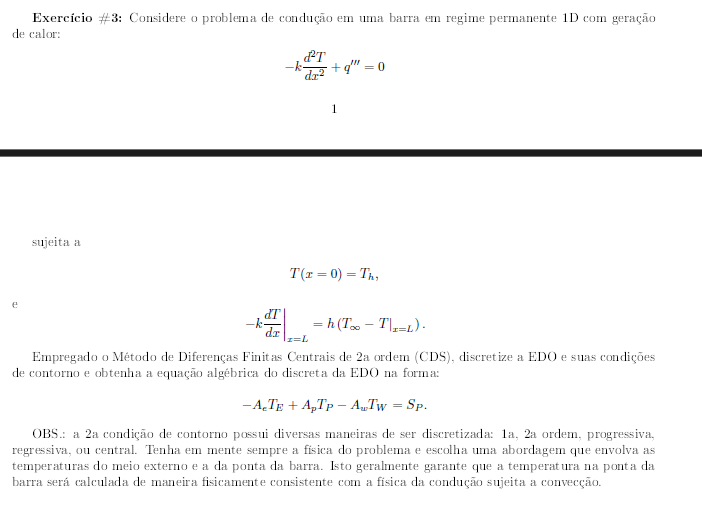

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

b = 1
a = 0
n = 100
h = 0.8
delta_x = (b-a)/n
i = np.arange(0,n+1)
xi = np.zeros(n)
for j in range(n):
    xi[j] = a + i[j]*delta_x

g = np.zeros(n)
U = np.zeros(n)
u = np.zeros(n)

In [2]:
k = 0.012
q = 1.226
L = 100
T_inf = 25
h = 1.12
T_L = 22
T_h = 85
x = np.arange(0,L,(1/n))
u = np.zeros(len(x))

for j in range(len(x)):
    u[j] = T_h + (q*x[j]**2)/(2*k) + x[j]*(-L*q + T_L*h - T_inf*h)/k
for j in range(len(xi)):
    g[j-1] = -k*((T_h + q*(xi[j]+delta_x)**2/(2*k) + (xi[j]+delta_x)*(-L*q + T_L*h - T_inf*h)/k) - 2*(T_h + q*xi[j]**2/(2*k) + xi[j]*(-L*q + T_L*h - T_inf*h)/k) + (T_h + q*(xi[j]-delta_x)**2/(2*k) + (xi[j]-delta_x)*(-L*q + T_L*h - T_inf*h)/k))/delta_x**2



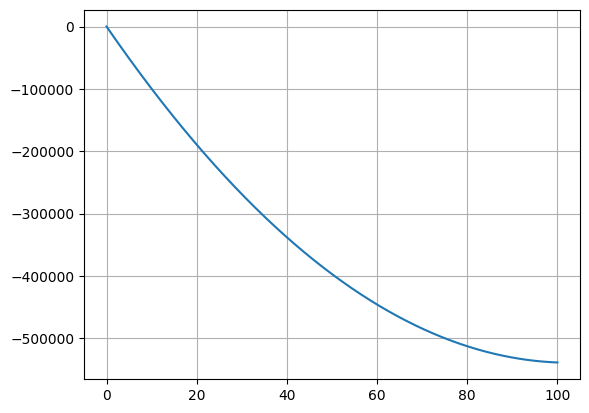

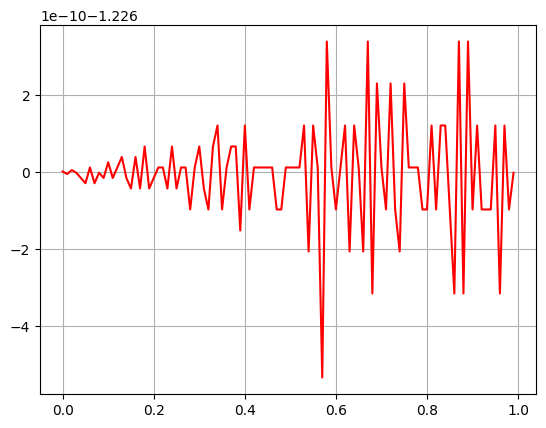

In [9]:
%matplotlib inline
gx, ax = plt.subplots()
ax.plot(x,u)
plt.grid()

gg,ax2 = plt.subplots()
ax2.plot(xi,g, 'red')
plt.grid()

## Algoritmo de solução da diferencial:
<code>T = sp.Function('T')
x,q,k,L,h, T_inf, T_L,T_h = sp.symbols(['x', 'q','k','L','h','T_inf','T_L','T_h'])
eq = sp.Eq(-k*T(x).diff(x,x)+q,0)
eq_solve = sp.dsolve(eq,T(x))

<code>C1, C2 = sp.symbols(['C1','C2'])
eq_solve = C1 + C2*x + q*x**2/(2*k)

<code>#condição de contorno: T(0) = Th 
cond_1 = sp.Eq(eq_solve.subs(x,0),T_h)
C1_solve = sp.solve(cond_1, C1)[0]
eq_solve =eq_solve.subs(C1,C1_solve)

<code>#condição 2: -kdT/dx = h(T_inf - T_L)
diff_eq_solve = sp.diff(eq_solve,x)
cond_2 = sp.Eq(-k*diff_eq_solve.subs(x,L), h*(T_inf-T_L))
C2_solve = sp.solve(cond_2,C2)[0]
eq_solve = eq_solve.subs(C2,C2_solve)
print(eq_solve)</code>